In [29]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
sns.set(style="whitegrid")
%config InlineBackend.figure_format = 'retina'
%config Completer.use_jedi = False

## From simple classification problem to market prediction


In [ ]:
from sklearn import linear_model

In [15]:
hours = np.array([0.5, 0.75, 1., 1.25, 1.5, 1.75, 1.75, 2.,
                  2.25, 2.5, 2.75, 3., 3.25, 3.5, 4., 4.25,
                  4.5, 4.75, 5., 5.5])
success = np.array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
                    0, 1, 1, 1, 1, 1, 1])

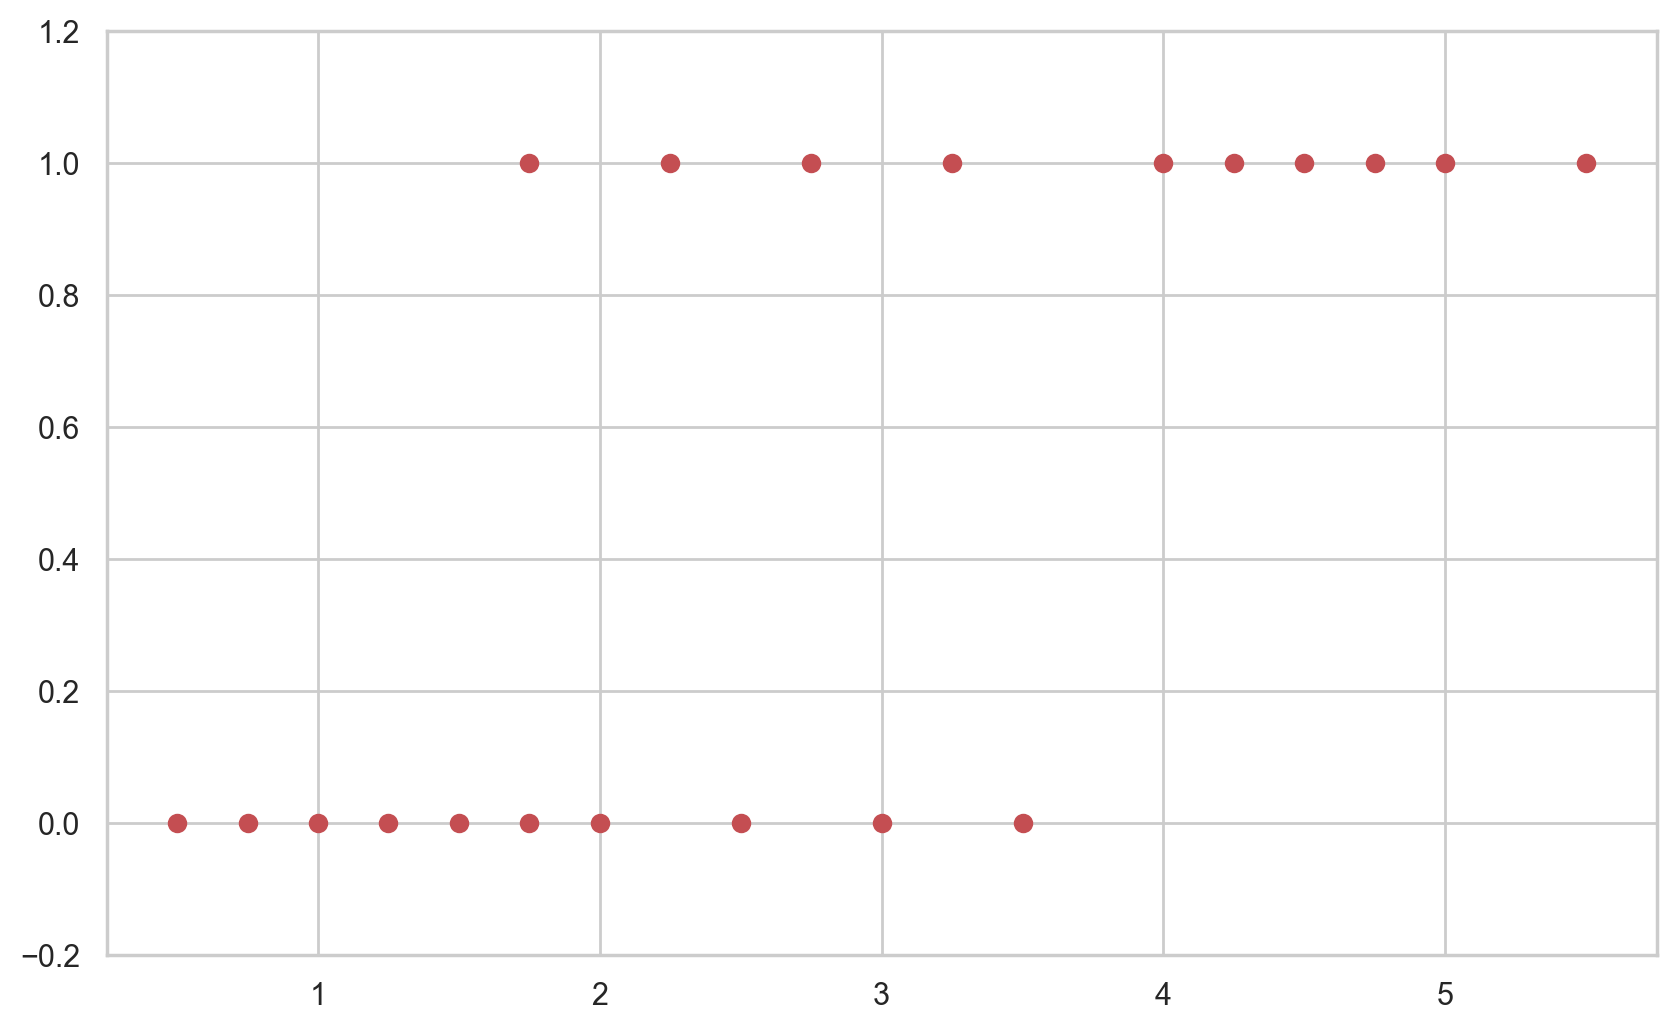

In [18]:
plt.figure(figsize=(10, 6))
plt.plot(hours, success, 'ro')
plt.ylim(-0.2, 1.2);

If we simply fit this data...

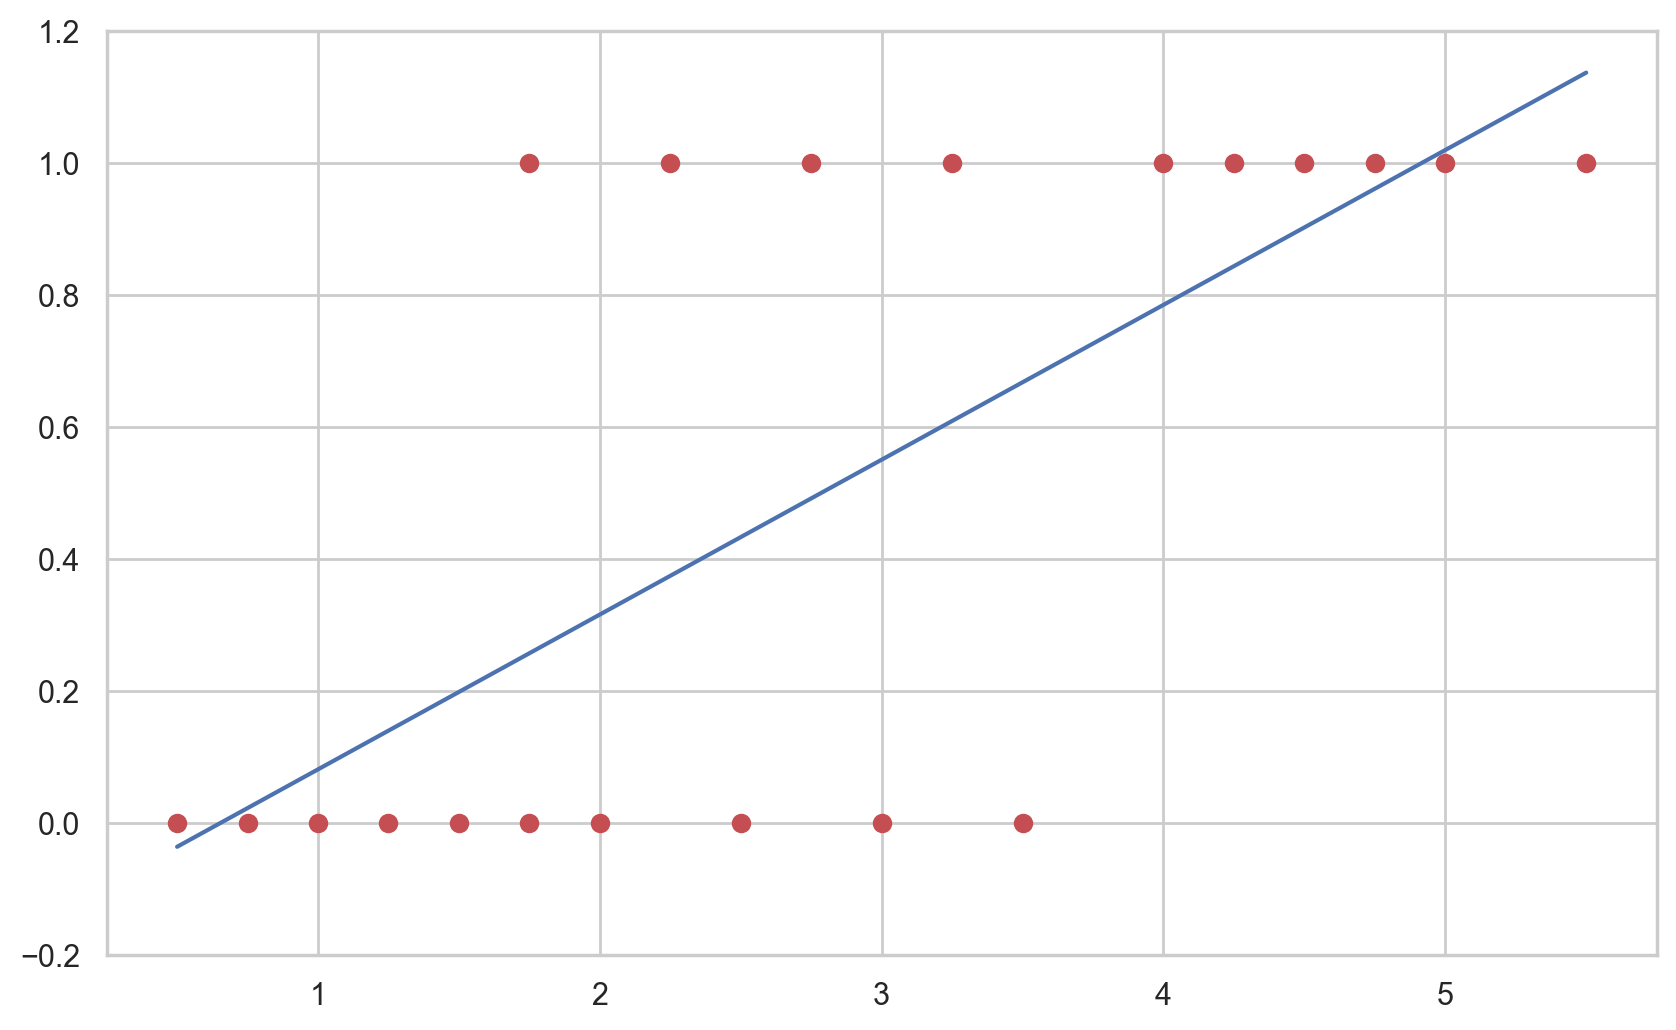

In [20]:
reg = np.polyfit(hours, success, deg=1)

plt.figure(figsize=(10, 6))
plt.plot(hours, success, 'ro')
plt.plot(hours, np.polyval(reg, hours), 'b')
plt.ylim(-0.2, 1.2);

### Let's start with logistic regression

In [21]:
lm = linear_model.LogisticRegression(solver='lbfgs')

In [22]:
hrs = hours.reshape(1, -1).T

In [23]:
lm.fit(hrs, success)

LogisticRegression()

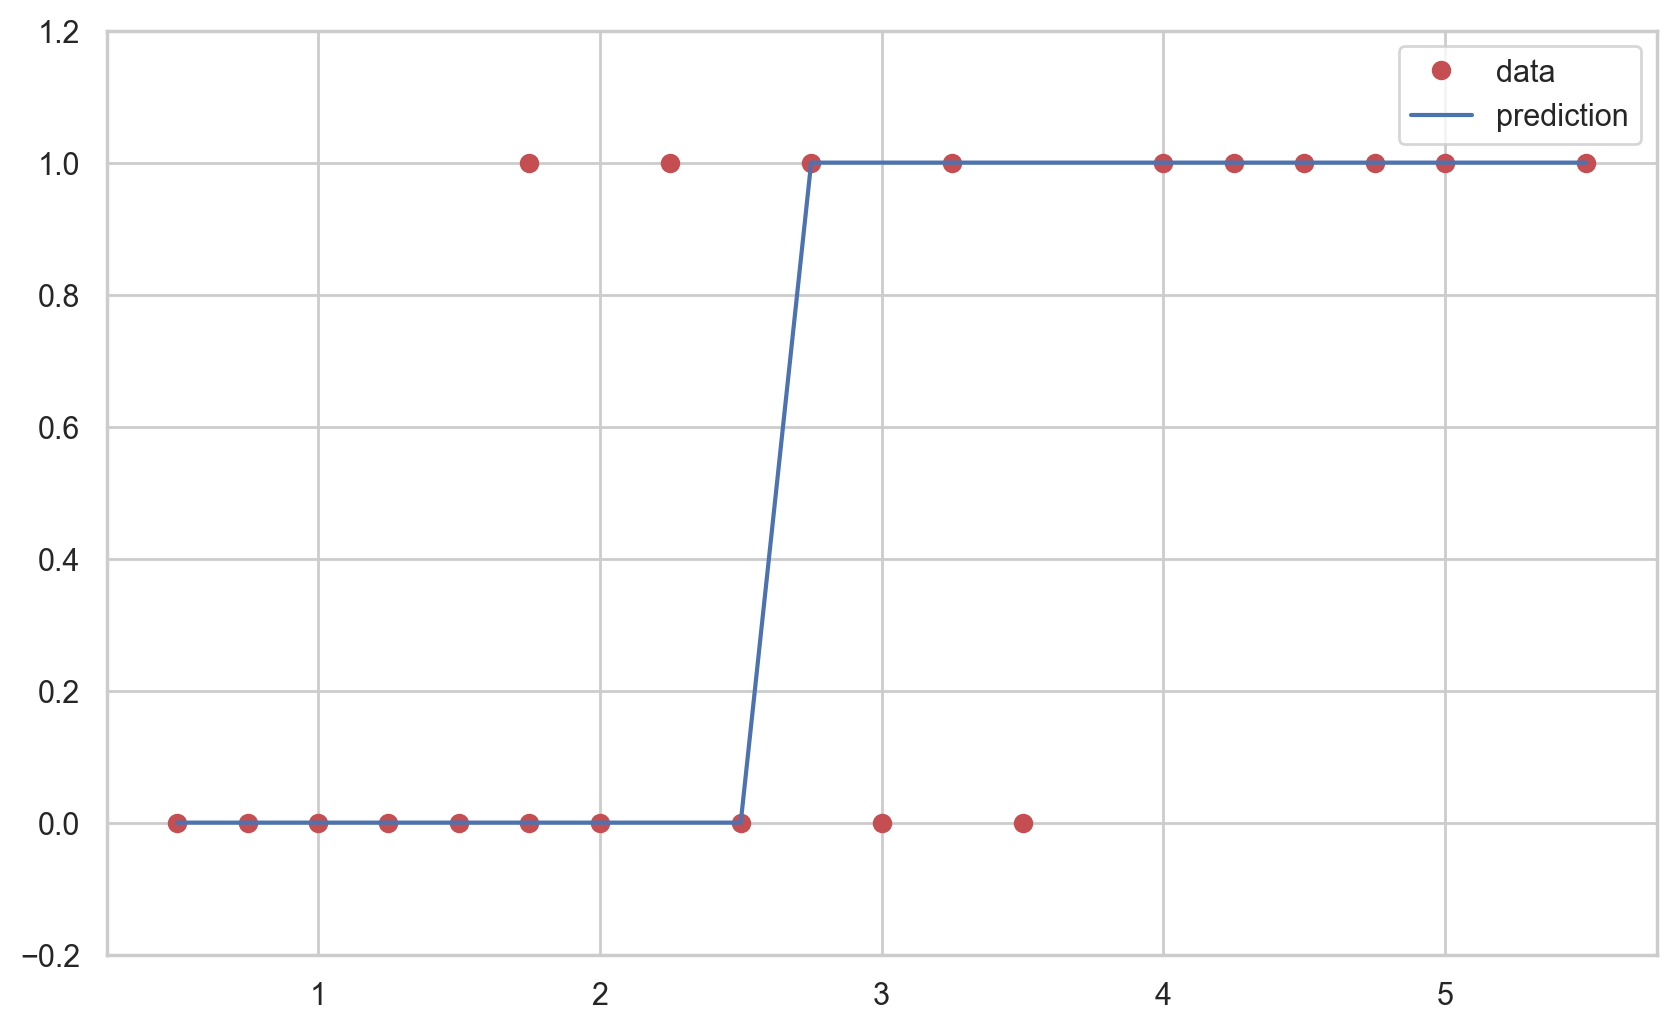

In [24]:
prediction = lm.predict(hrs)

plt.figure(figsize=(10, 6))
plt.plot(hours, success, 'ro', label='data')
plt.plot(hours, prediction, 'b', label='prediction')
plt.legend(loc=0)
plt.ylim(-0.2, 1.2);

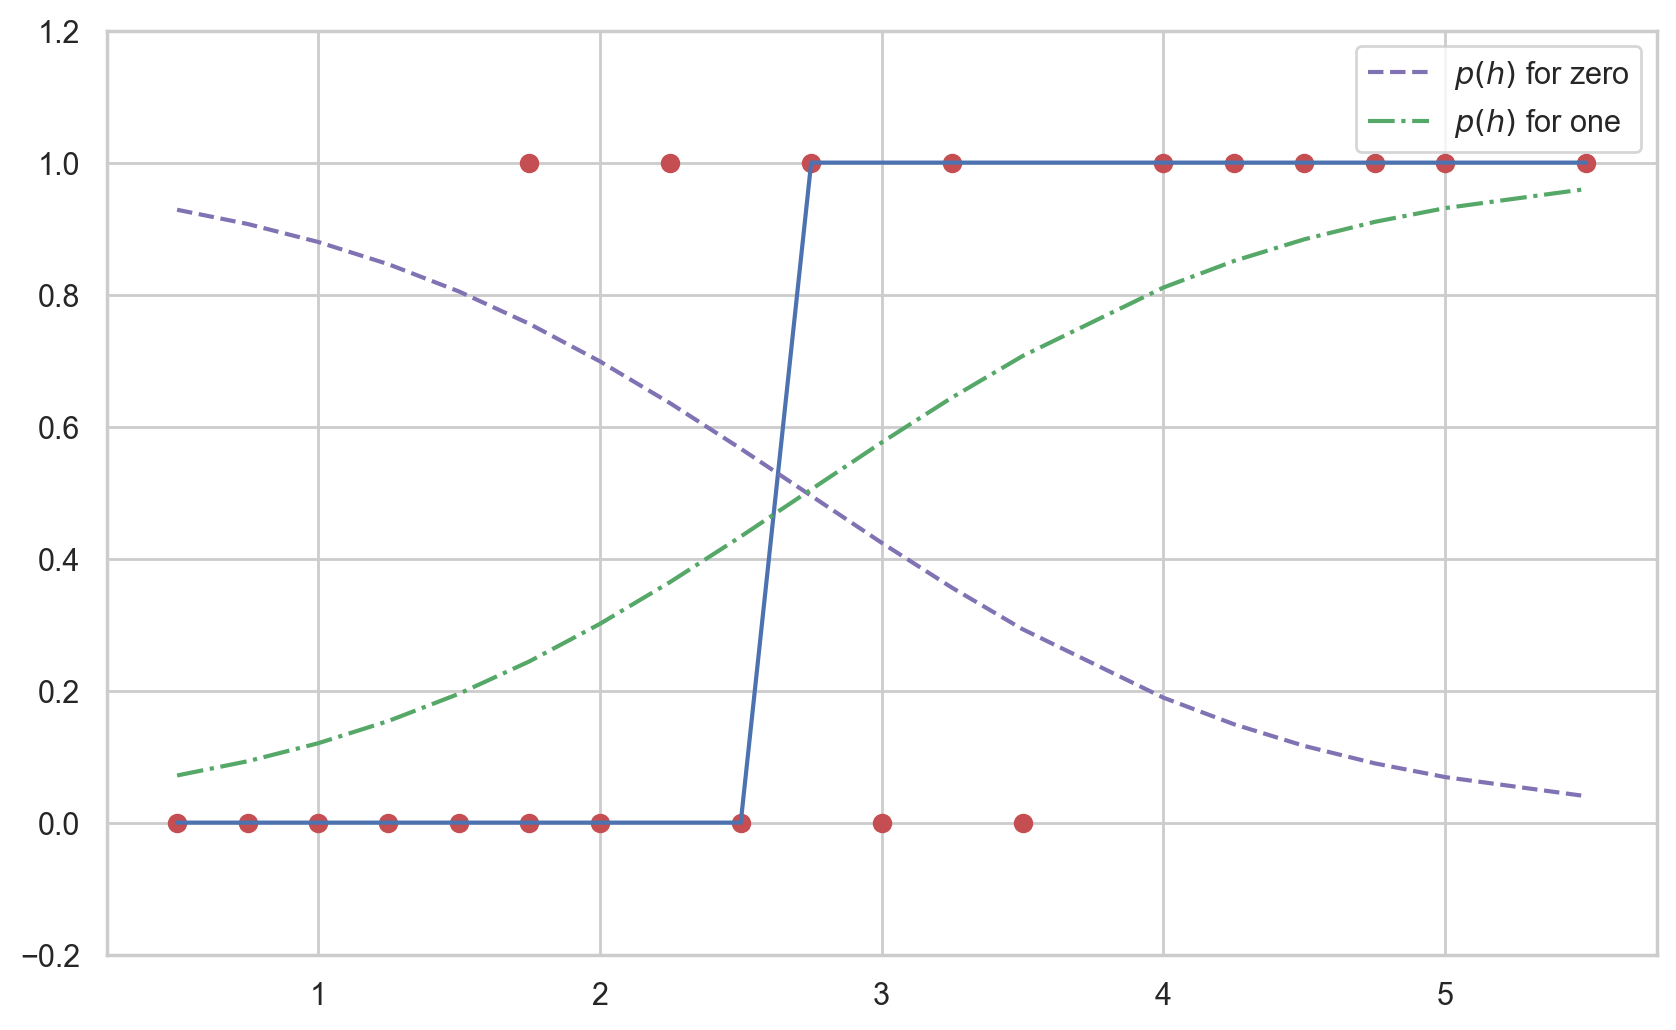

In [25]:
prob = lm.predict_proba(hrs)

plt.figure(figsize=(10, 6))
plt.plot(hours, success, 'ro')
plt.plot(hours, prediction, 'b')
plt.plot(hours, prob.T[0], 'm--',
         label='$p(h)$ for zero')
plt.plot(hours, prob.T[1], 'g-.',
         label='$p(h)$ for one')
plt.ylim(-0.2, 1.2)
plt.legend(loc=0);

### Now using Deep Learning

Neural network using the same data

In [32]:
from sklearn.neural_network import MLPClassifier

In [30]:
data = pd.DataFrame({'hours': hours, 'success': success})

In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   hours    20 non-null     float64
 1   success  20 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 448.0 bytes


In [33]:
model = MLPClassifier(hidden_layer_sizes=[32],
                     max_iter=1000, random_state=100,
                     shuffle=False)

In [34]:
model.fit(data['hours'].values.reshape(-1, 1), data['success'])

MLPClassifier(hidden_layer_sizes=[32], max_iter=1000, random_state=100,
              shuffle=False)

In [35]:
data['prediction'] = model.predict(data['hours'].values.reshape(-1, 1))

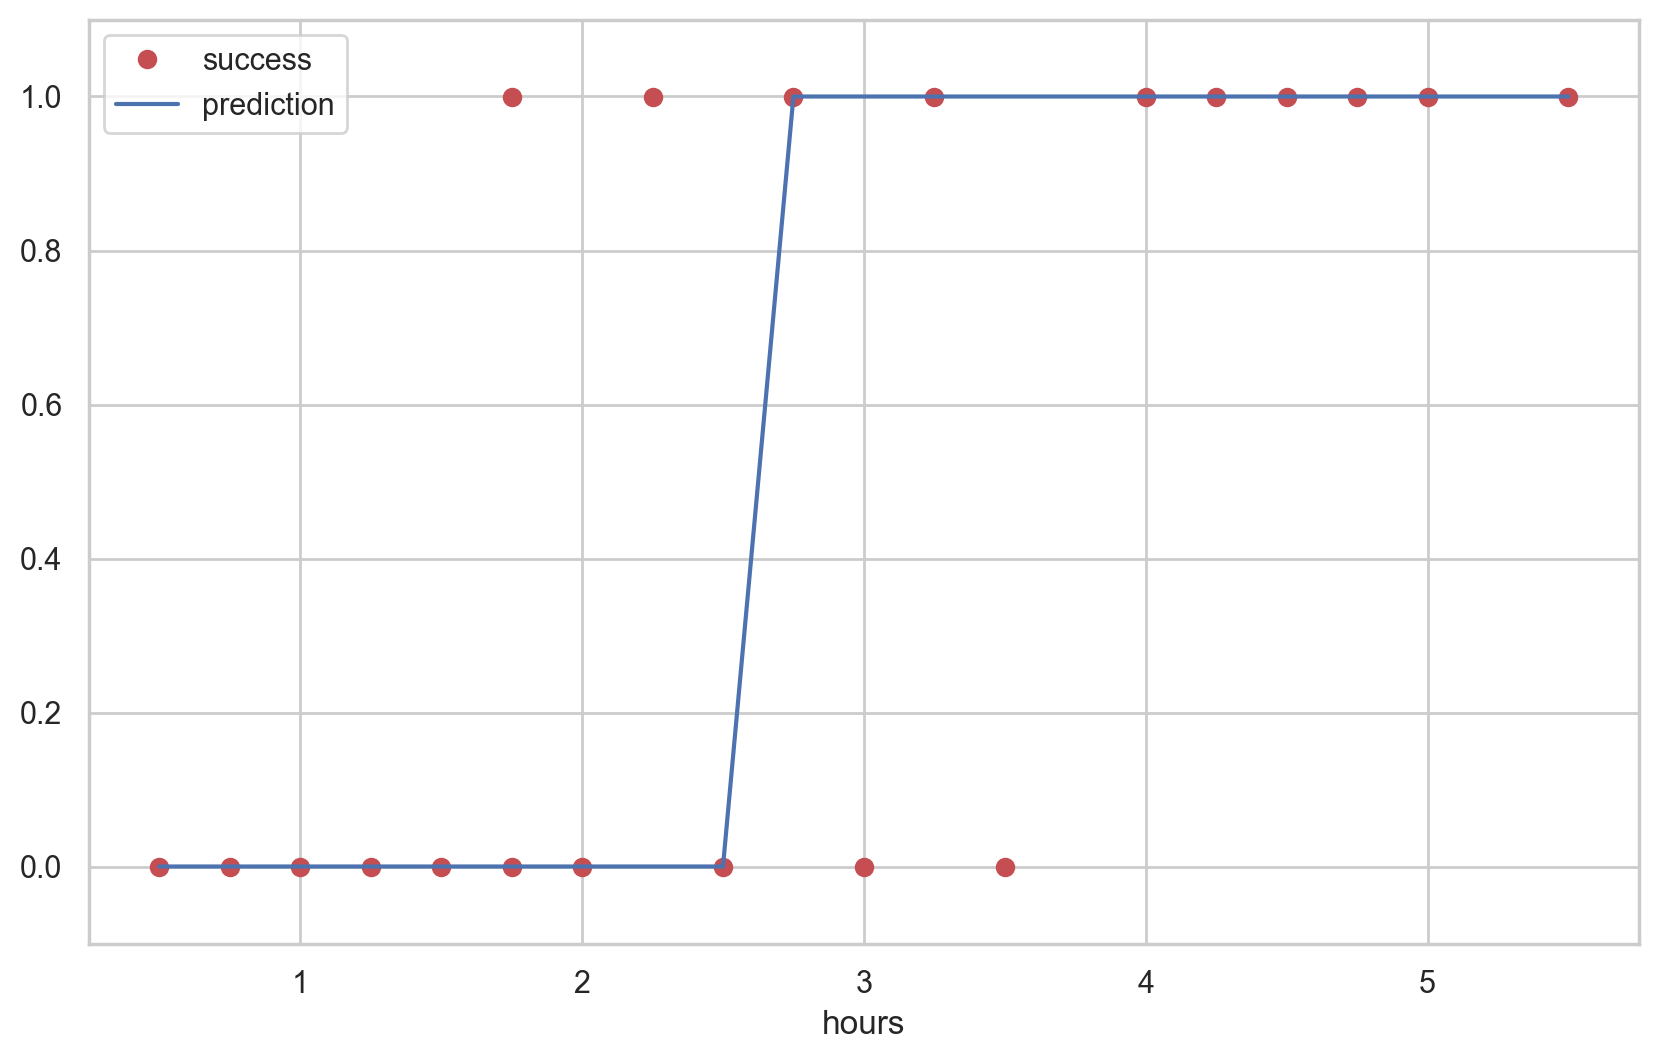

In [36]:
data.plot(x='hours', y=['success', 'prediction'],
          style=['ro', 'b-'], ylim=[-.1, 1.1],
          figsize=(10, 6));

### Logistic Regression to Predict Market Direction


In [40]:
import yfinance as yf

In [93]:
from sklearn.metrics import accuracy_score

In [113]:
gold = yf.download('GLD')

data = pd.DataFrame(gold['Close'])
data.rename(columns={"GLD": "price"}, inplace=True)
data['return'] = np.log(data['price']).diff()
data.dropna(inplace=True)

[*********************100%***********************]  1 of 1 completed


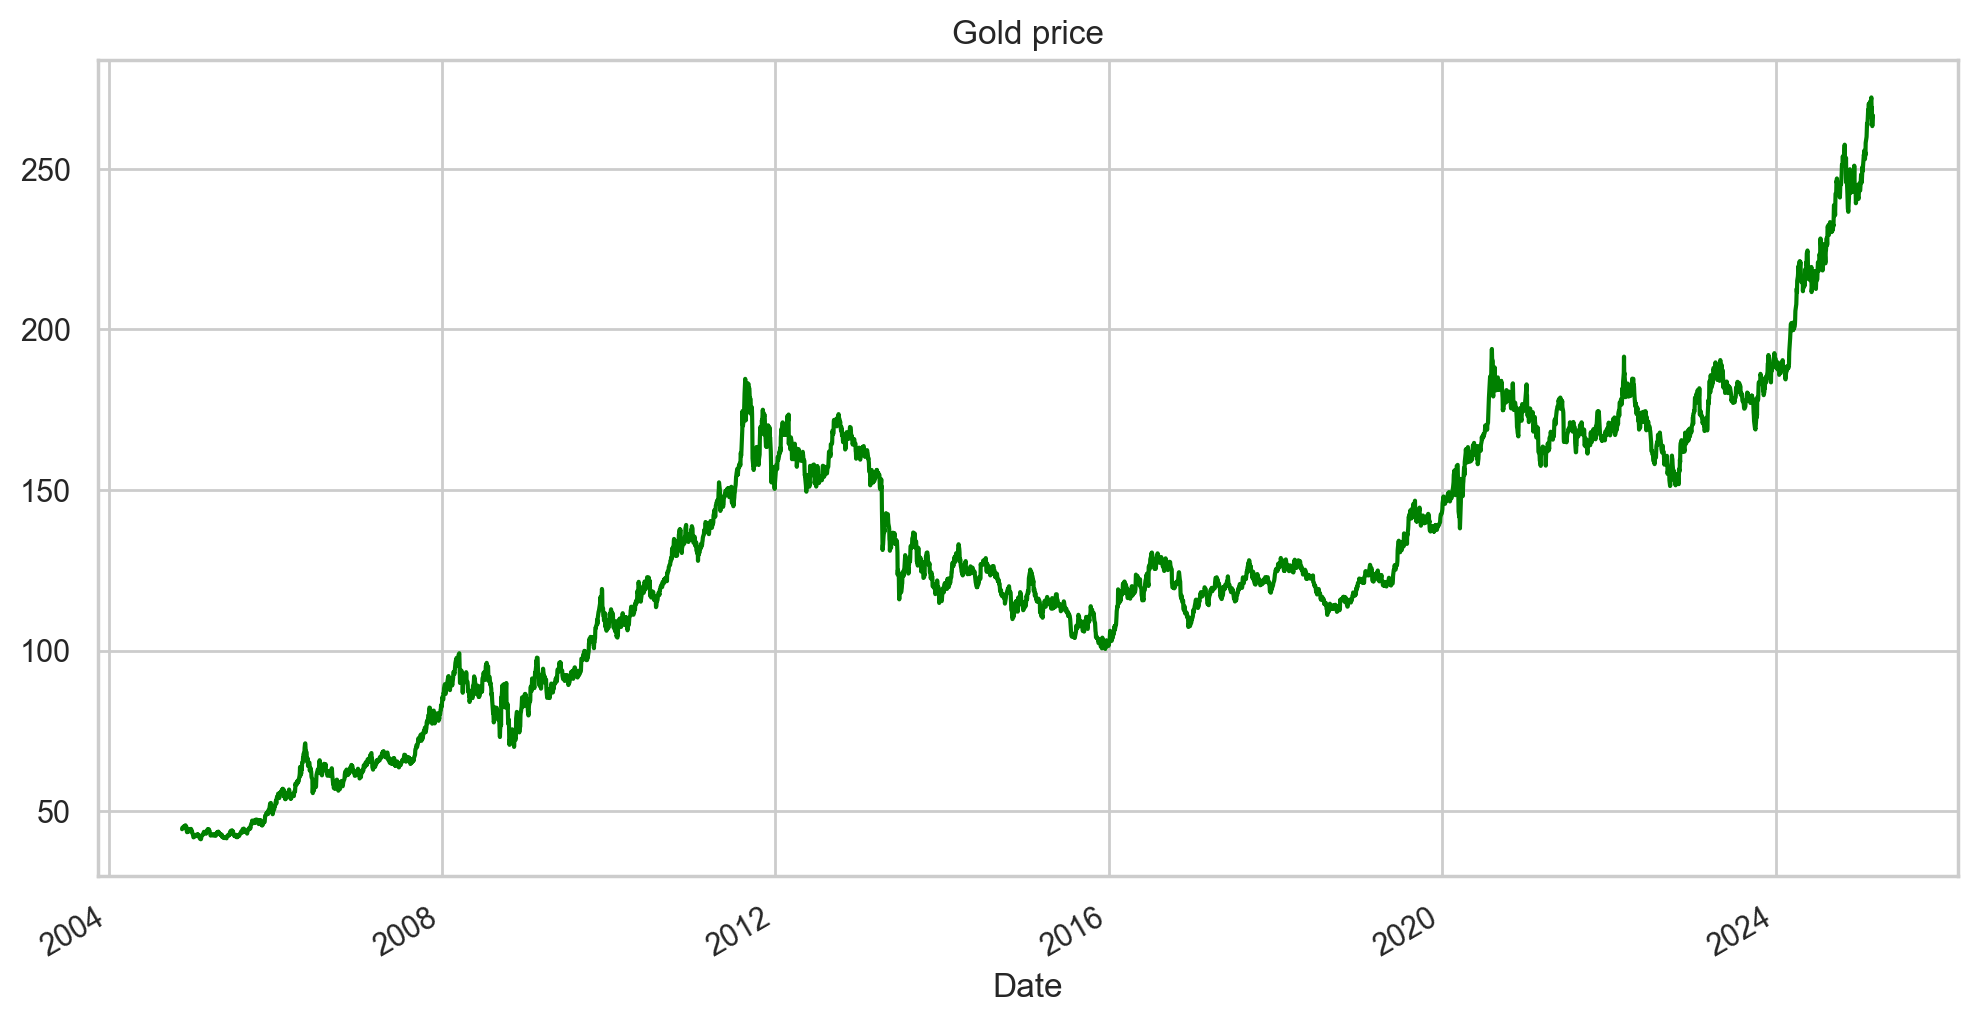

In [114]:
plt.figure(figsize=(12, 6))
data['price'].plot(color='green', title="Gold price")
plt.show()

In [104]:
lags = 5
cols = []

for lag in range(1, lags + 1):
    col = 'lag_{}'.format(lag)
    data[col] = data['return'].shift(lag)
    cols.append(col)

In [105]:
data.dropna(inplace=True)
data.head()

Ticker,price,return,lag_1,lag_2,lag_3,prediction,strategy,lag_4,lag_5
Date,,,,,,,,,
2004-12-02,44.950001,-0.009521,0.005746,-0.006187,0.002426,1.0,-0.009521,0.005313,0.006682
2004-12-03,45.599998,0.014357,-0.009521,0.005746,-0.006187,1.0,0.014357,0.002426,0.005313
2004-12-06,45.169998,-0.009475,0.014357,-0.009521,0.005746,1.0,-0.009475,-0.006187,0.002426
2004-12-07,45.110001,-0.001329,-0.009475,0.014357,-0.009521,1.0,-0.001329,0.005746,-0.006187
2004-12-08,44.009998,-0.024687,-0.001329,-0.009475,0.014357,1.0,-0.024687,-0.009521,0.005746


In [95]:
lm = linear_model.LogisticRegression(C=1e7, solver='lbfgs',
                                     multi_class='auto',
                                     max_iter=1000)

In [106]:
lm.fit(data[cols], np.sign(data['return']))

LogisticRegression(C=10000000.0, max_iter=1000)

In [107]:
data['prediction'] = lm.predict(data[cols])

In [108]:
data['prediction'].value_counts()

prediction
 1.0    4914
-1.0     180
Name: count, dtype: int64

In [109]:
hits = np.sign(data['return'].iloc[lags:] *
               data['prediction'].iloc[lags:]
              ).value_counts()

In [110]:
hits

 1.0    2689
-1.0    2380
 0.0      20
Name: count, dtype: int64

In [111]:
accuracy_score(data['prediction'],
               np.sign(data['return']))

0.5280722418531606

In [102]:
data['strategy'] = data['prediction'] * data['return']

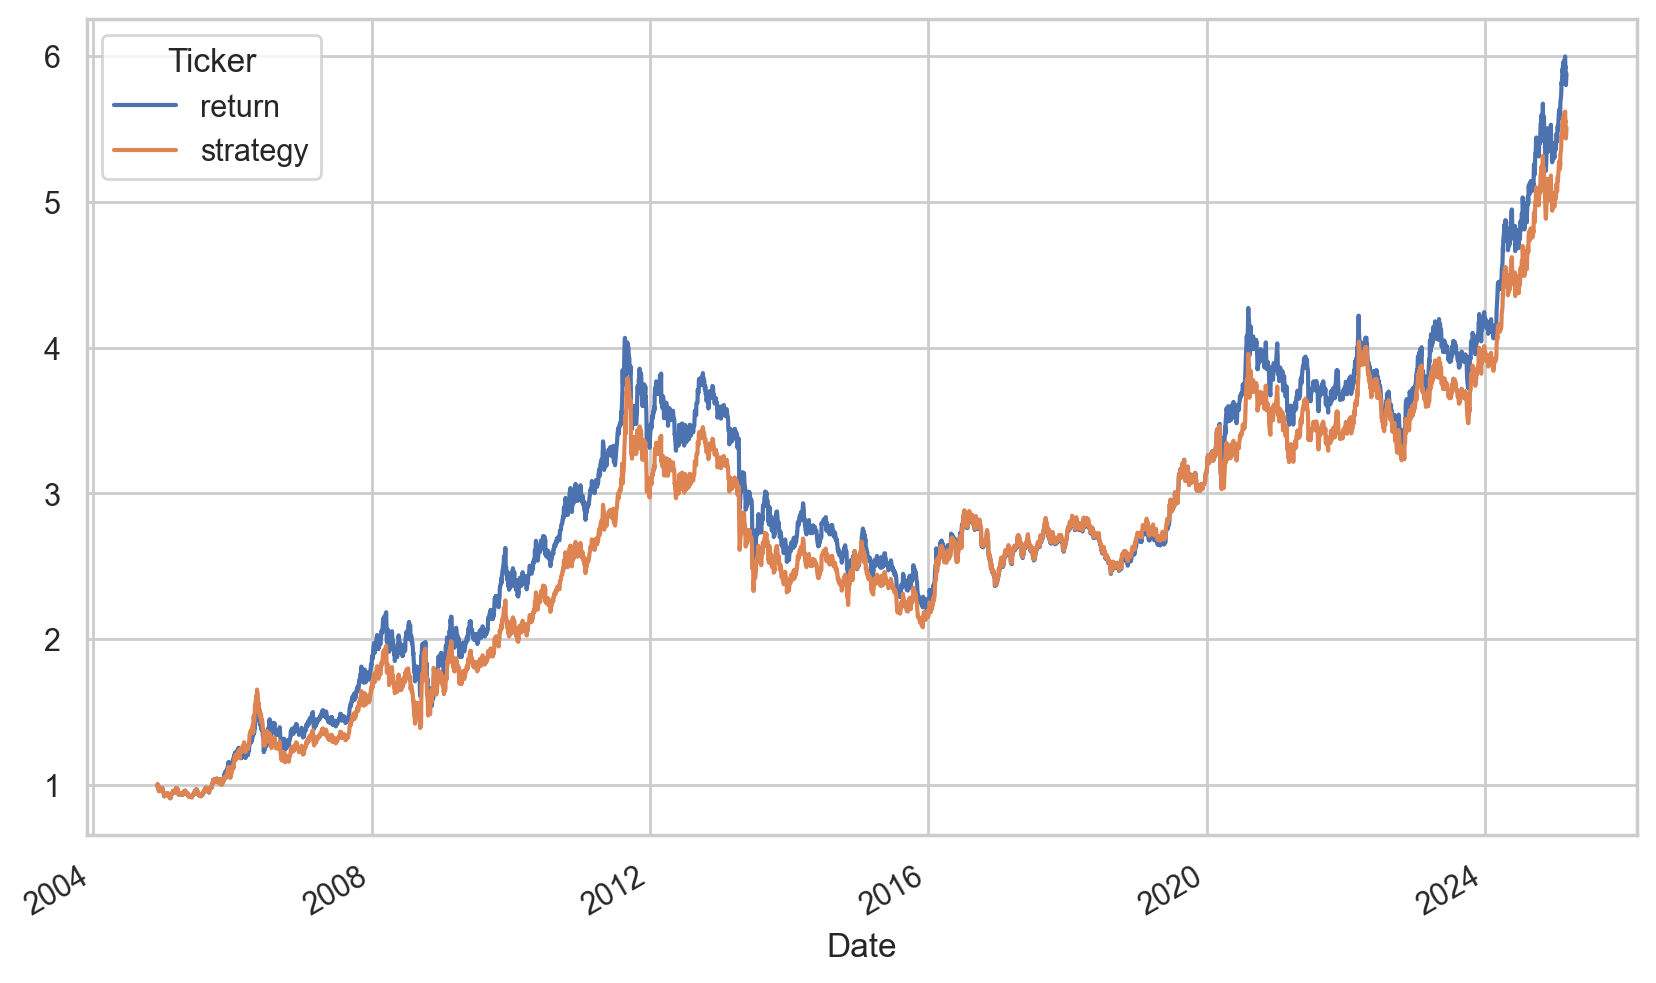

In [112]:
data[['return', 'strategy']].cumsum().apply(np.exp).plot(
                                        figsize=(10, 6));

### Deep Neural Networks to Predict Market Direction

We need to run this in a different environment, as tensorflow is I don't want to modify my current env

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

In [120]:
df = pd.read_csv('../FX/mktdata_EURUSD.csv', index_col=0, parse_dates=True, dayfirst=True).dropna()

In [122]:
data = pd.DataFrame(df['Spot'])
data.rename(columns={'Spot': 'price'}, inplace=True)

In [124]:
data['return'] = np.log(data['price']).diff()
data.dropna(inplace=True)

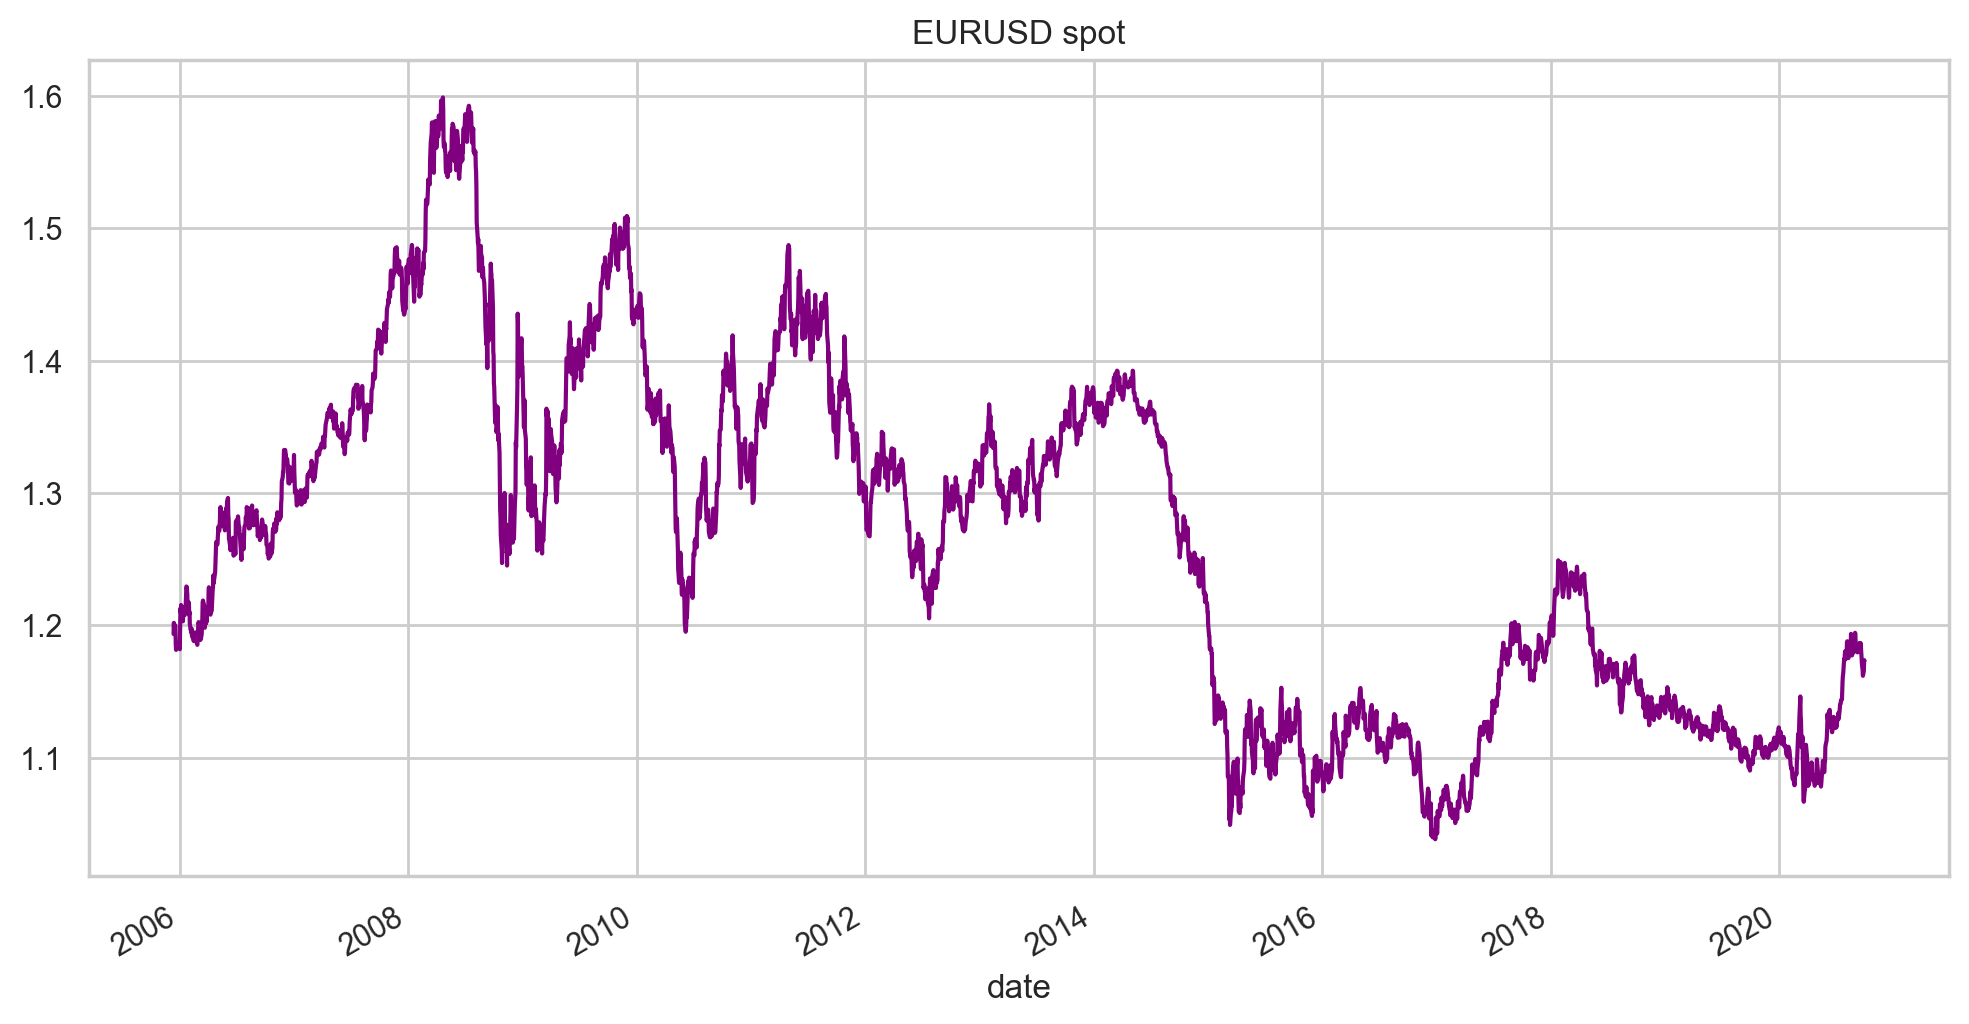

In [125]:
plt.figure(figsize=(12, 6))
data['price'].plot(color='purple', title="EURUSD spot")
plt.show()

In [126]:
lags = 5
cols = []
for lag in range(1, lags + 1):
    col = f'lag_{lag}'
    data[col] = data['return'].shift(lag)
    cols.append(col)
data.dropna(inplace=True)

In [128]:
data.round(4).tail()

,price,return,lag_1,lag_2,lag_3,lag_4,lag_5
date,,,,,,,
2020-09-24,1.1663,-0.0015,-0.0020,-0.0032,-0.0106,0.0037,-0.0009
2020-09-25,1.1619,-0.0038,-0.0015,-0.0020,-0.0032,-0.0106,0.0037
2020-09-28,1.1656,0.0032,-0.0038,-0.0015,-0.0020,-0.0032,-0.0106
2020-09-29,1.1738,0.0070,0.0032,-0.0038,-0.0015,-0.0020,-0.0032
2020-09-30,1.1733,-0.0004,0.0070,0.0032,-0.0038,-0.0015,-0.0020


In [ ]:
optimizer = keras.optimizers.Adam(learning_rate=0.0001)

In [132]:
def set_seeds(seed=100):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(100)

In [ ]:
set_seeds()
model = Sequential()
model.add(Dense(64, activation='relu',
        input_shape=(lags,)))
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid')) # <5>
model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy'])